# Chapter 50 — When Data Became Too Large to Listen To
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 50 — When Data Became Too Large to Listen To.

There was a time when a test engineer could listen to every data channel. The oscillograph traces scrolled by on paper; a skilled analyst could read a full day's test in an afternoon. Then channel counts began to climb — 16 channels, 64, 256, 512. Sampling rates rose to capture dynamic events. Tests grew from hours to weeks. By the 2020s, a single instrumented fatigue test program could generate 18 GB per eight-hour shift and tens of terabytes over its lifetime. The data was no longer something a human could hear. It became something that had to be managed.

The *analyst bottleneck* is the gap between the rate at which data is generated and the rate at which a human can extract meaning from it. A well-trained analyst can review perhaps 200 MB of strain data per day — examining time histories, identifying anomalies, flagging limit exceedances. A modern 2000-channel acquisition system at 10 kSa/s generates that same 200 MB every few seconds. The bar charts below make the scale concrete: from tens of kilobytes per test in the 1960s to hundreds of terabytes per program today, with analyst capacity essentially flat throughout.

Machine learning is not an academic curiosity in this context. It is the only tool that scales to the problem. The chapters that follow build the case for why, and how, AI methods can be brought to bear on data that would otherwise go unanalyzed.

**This notebook demonstrates:**
1. Data volume growth by era (1960s–2020s) and the analyst bottleneck that made automated analysis a necessity rather than a luxury

In [1]:
# Colab setup: uncomment the next line to install dependencies.
# !pip install matplotlib

from collections import namedtuple
from pathlib import Path

import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Output directory for the figure the book includes. Do NOT change this path or
# the saved filename — the manuscript references these exact files.
OUT_DIR = Path("../src/media/ch50")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Data Volume by Era and the Analyst Bottleneck

The left chart plots total data generated per test program, spanning six representative eras from a single-channel 1960s oscillograph to a 2000-channel, month-long 2020s fatigue test. The vertical axis is logarithmic because no other scale fits — the range spans roughly ten orders of magnitude, from tens of kilobytes to hundreds of terabytes.

The right chart converts that volume to analyst-days at a constant review rate of 200 MB per day. In the 1960s, a single analyst could review an entire program's data in a day. By the 2000s, a single test program required thousands of analyst-days to review manually — more than the entire career of any individual engineer. By the 2020s, the number is not a constraint to be optimized; it is a physical impossibility. No amount of hiring closes the gap.

This is the forcing function for everything in Part 9. The question is not whether to automate analysis — that decision was made by the data itself. The question is how to do it without losing the engineering judgment that made the human analyst valuable in the first place.

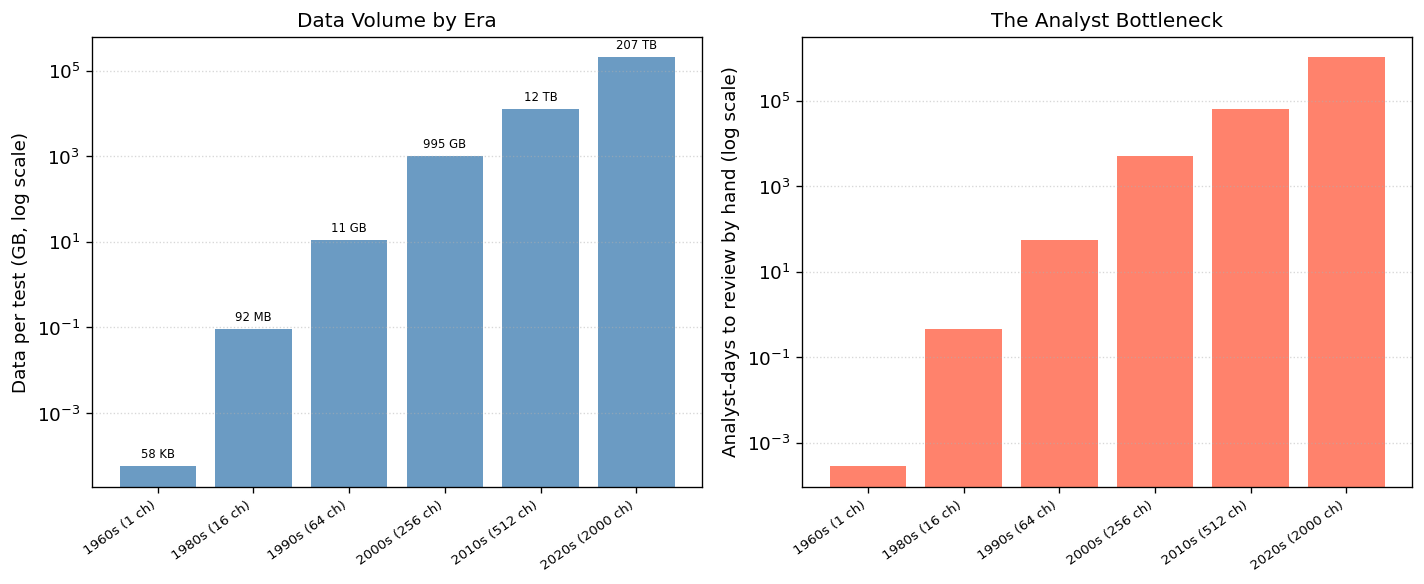

In [2]:
# Each era is a representative acquisition configuration. Fields: channel count,
# sample rate (Sa/s per channel), test duration (s), and bytes per sample (the
# ADC word width — 2 bytes for 16-bit, 3 for 24-bit, 4 for 32-bit storage).
EraConfig = namedtuple(
    "EraConfig", "label channels sample_rate_hz duration_s bytes_per_sample")

ERAS = [
    EraConfig("1960s (1 ch)",       1,      1,   8 * 3600, 2),
    EraConfig("1980s (16 ch)",     16,    100,   8 * 3600, 2),
    EraConfig("1990s (64 ch)",     64,   1000,  24 * 3600, 2),
    EraConfig("2000s (256 ch)",   256,   5000,  72 * 3600, 3),
    EraConfig("2010s (512 ch)",   512,  10000, 168 * 3600, 4),
    EraConfig("2020s (2000 ch)", 2000,  10000, 720 * 3600, 4),
]

BYTES_PER_GB = 1e9
MB_PER_GB = 1e3
ANALYST_REVIEW_MB_PER_DAY = 200.0  # data a skilled analyst reviews by hand per day


def data_volume_gb(era):
    """Total raw data (GB) an era's configuration produces over one test."""
    total_bytes = (era.channels * era.sample_rate_hz
                   * era.duration_s * era.bytes_per_sample)
    return total_bytes / BYTES_PER_GB


def analyst_days(volume_gb):
    """Analyst-days needed to review a volume by hand at the constant review rate."""
    return volume_gb * MB_PER_GB / ANALYST_REVIEW_MB_PER_DAY


def human_readable(volume_gb):
    """Format a GB value with the most legible unit (KB / MB / GB / TB)."""
    megabytes = volume_gb * MB_PER_GB
    if megabytes < 1:
        return f"{megabytes * 1e3:.0f} KB"
    if megabytes < MB_PER_GB:
        return f"{megabytes:.0f} MB"
    if volume_gb < 1e3:
        return f"{volume_gb:.0f} GB"
    return f"{volume_gb / 1e3:.0f} TB"


labels = [era.label for era in ERAS]
volumes_gb = [data_volume_gb(era) for era in ERAS]
review_days = [analyst_days(v) for v in volumes_gb]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: raw data volume per test program, by era.
bars = axes[0].bar(range(len(labels)), volumes_gb, color='steelblue', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Data per test (GB, log scale)')
axes[0].set_title('Data Volume by Era')
axes[0].grid(True, axis='y', linestyle=':', alpha=0.5)
for bar, volume in zip(bars, volumes_gb):
    axes[0].text(bar.get_x() + bar.get_width() / 2, volume * 1.6,
                 human_readable(volume), ha='center', fontsize=7)

# Right panel: the same volumes expressed as analyst-days of manual review.
axes[1].bar(range(len(labels)), review_days, color='tomato', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Analyst-days to review by hand (log scale)')
axes[1].set_title('The Analyst Bottleneck')
axes[1].grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig50_nb1_data_volume_evolution.png',
            bbox_inches='tight', dpi=300)
plt.show()

---
## Where to take this next

This notebook argues the scale problem with a handful of representative eras. Three concrete ways to build on it:

1. **Plug in a system you actually run.** Replace the `ERAS` table with the channel count, sample rate, ADC word width, and test duration of one of your own rigs, and read off where it lands on the analyst-bottleneck chart. The `data_volume_gb` and `analyst_days` helpers already do the arithmetic.
2. **Model a smarter review workflow.** The flat 200 MB/day rate assumes an analyst reads raw traces. Add a second `review_days` curve for a triage workflow — automatic limit-exceedance flagging first, then human review of only the flagged windows — and see how far it pushes the crossing point out. That is exactly the automation Part 9 develops.
3. **Add a storage-economics axis.** Multiply each era's volume by the cost per GB of its dominant medium (tape, spinning disk, cloud object storage) to show that the cost of *keeping* the data fell on a very different curve than the cost of *interpreting* it — the gap this chapter is really about.